In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df_raw = pd.read_csv("/content/ev_charging_sessions (3).csv")
df = df_raw.copy()
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 86,923  |  Columns: 15


,session_id,start_time,city,station_id,location_type,charger_type,vehicle_type,user_type,start_soc_pct,wait_time_min,session_duration_min,energy_kwh,revenue_inr,energy_cost_inr,session_status
0,EVS-0000001,2025-01-01 00:10:35,Bengaluru,BLR-013,Residential Society,AC 7kW,2-Wheeler,Pay-per-Use,33.7,0.0,53.0,2.47,25.19,18.94,Completed
1,EVS-0000002,2025-01-01 00:43:15,Jaipur,JAI-003,Transit Hub,DC 30kW,Fleet Cab,Fleet Contract,36.2,0.0,46.0,12.60,149.56,98.31,Completed
2,EVS-0000003,2025-01-01 00:56:31,Delhi NCR,DEL-005,Shopping Mall,DC 60kW,SUV/Premium,Pay-per-Use,35.5,0.0,58.0,41.61,742.69,281.80,Completed
3,EVS-0000004,2025-01-01 00:58:31,Delhi NCR,DEL-005,Shopping Mall,DC 60kW,Hatchback/Sedan,Subscriber,28.3,0.0,38.0,17.86,280.54,121.69,Completed
4,EVS-0000005,2025-01-01 01:10:10,Kolkata,CCU-001,Shopping Mall,DC 60kW,SUV/Premium,Pay-per-Use,29.6,0.0,51.0,31.61,552.97,283.86,Completed


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86923 entries, 0 to 86922
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   session_id            86923 non-null  object 
 1   start_time            86923 non-null  object 
 2   city                  86923 non-null  object 
 3   station_id            86923 non-null  object 
 4   location_type         86923 non-null  object 
 5   charger_type          86922 non-null  object 
 6   vehicle_type          85836 non-null  object 
 7   user_type             86922 non-null  object 
 8   start_soc_pct         83844 non-null  float64
 9   wait_time_min         85212 non-null  float64
 10  session_duration_min  86922 non-null  float64
 11  energy_kwh            86922 non-null  float64
 12  revenue_inr           86922 non-null  float64
 13  energy_cost_inr       86922 non-null  float64
 14  session_status        86922 non-null  object 
dtypes: float64(6), obje

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
session_id,86923,86828,EVS-0082147,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_time,86923,86616,2025-07-17 10:40:47,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,86923,9,Delhi NCR,18212,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station_id,86923,105,BLR-002,7306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_type,86923,7,Office Park,25160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charger_type,86922,4,AC 7kW,34083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicle_type,85836,5,Hatchback/Sedan,27754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_type,86922,3,Pay-per-Use,47596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
start_soc_pct,83844.0,NaN,NaN,NaN,32.085875,19.429767,3.0,16.3,29.65,45.5,82.0
wait_time_min,85212.0,NaN,NaN,NaN,4.855302,11.358143,0.0,0.0,0.0,4.0,90.0


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report.missing_count > 0].sort_values("missing_pct", ascending=False)
missing_report


,missing_count,missing_pct
start_soc_pct,3079,3.54
wait_time_min,1711,1.97
vehicle_type,1087,1.25
charger_type,1,0.00
user_type,1,0.00
session_duration_min,1,0.00
energy_kwh,1,0.00
revenue_inr,1,0.00
energy_cost_inr,1,0.00
session_status,1,0.00


In [6]:
# Is missingness related to session outcome or customer segment, or is it random (MCAR)?
print("wait_time_min missing % by session_status:")
print((df.groupby("session_status")["wait_time_min"].apply(lambda s: s.isnull().mean()*100)).round(2))
print("\nstart_soc_pct missing % by session_status:")
print((df.groupby("session_status")["start_soc_pct"].apply(lambda s: s.isnull().mean()*100)).round(2))
print("\nvehicle_type missing % by user_type:")
print((df.groupby("user_type")["vehicle_type"].apply(lambda s: s.isnull().mean()*100)).round(2))


wait_time_min missing % by session_status:
session_status
Completed      1.96
Failed         1.75
Interrupted    2.36
Name: wait_time_min, dtype: float64

start_soc_pct missing % by session_status:
session_status
Completed      3.53
Failed         3.36
Interrupted    4.03
Name: start_soc_pct, dtype: float64

vehicle_type missing % by user_type:
user_type
Fleet Contract    1.28
Pay-per-Use       1.20
Subscriber        1.33
Name: vehicle_type, dtype: float64


In [7]:
# 2.1 Apply the imputations above
df["start_soc_pct"] = df.groupby("charger_type")["start_soc_pct"].transform(lambda s: s.fillna(s.median()))
df["wait_time_min"] = df["wait_time_min"].fillna(0)
df["vehicle_type"] = df["vehicle_type"].fillna("Unknown")

print("Remaining nulls:", df.isnull().sum().sum())


Remaining nulls: 8


In [9]:
exact_dupes = df.duplicated().sum()
id_dupes = df.duplicated(subset=["session_id"]).sum()
print(f"Fully duplicated rows: {exact_dupes}")
print(f"Duplicated session_id values: {id_dupes}")
df[df.duplicated(keep=False)].sort_values("session_id").head(4)


Fully duplicated rows: 95
Duplicated session_id values: 95


,session_id,start_time,city,station_id,location_type,charger_type,vehicle_type,user_type,start_soc_pct,wait_time_min,session_duration_min,energy_kwh,revenue_inr,energy_cost_inr,session_status
2240,EVS-0002241,2025-01-09 04:00:59,Delhi NCR,DEL-010,Office Park,AC 7kW,SUV/Premium,Pay-per-Use,38.5,0.0,206.0,24.46,249.46,187.15,Completed
2241,EVS-0002241,2025-01-09 04:00:59,Delhi NCR,DEL-010,Office Park,AC 7kW,SUV/Premium,Pay-per-Use,38.5,0.0,206.0,24.46,249.46,187.15,Completed
3712,EVS-0003712,2025-01-14 11:44:47,Bengaluru,BLR-024,Fuel Station,DC 30kW,Fleet Cab,Fleet Contract,37.2,0.0,49.0,16.55,238.30,132.73,Completed
3713,EVS-0003712,2025-01-14 11:44:47,Bengaluru,BLR-024,Fuel Station,DC 30kW,Fleet Cab,Fleet Contract,37.2,0.0,49.0,16.55,238.30,132.73,Completed


In [10]:
before = len(df)
df = df.drop_duplicates(subset=["session_id"], keep="first").reset_index(drop=True)
print(f"Dropped {before - len(df):,} duplicate rows -> {len(df):,} rows remain")


Dropped 95 duplicate rows -> 86,828 rows remain


In [11]:
df["start_time"] = pd.to_datetime(df["start_time"])
for c in ["city", "station_id", "location_type", "charger_type", "vehicle_type", "user_type", "session_status"]:
    df[c] = df[c].astype("category")
df.dtypes


,0
session_id,object
start_time,datetime64[ns]
city,category
station_id,category
location_type,category
charger_type,category
vehicle_type,category
user_type,category
start_soc_pct,float64
wait_time_min,float64


In [12]:
# Range checks on domain-bounded numeric fields
checks = {
    "start_soc_pct out of [0,100]": ((df.start_soc_pct < 0) | (df.start_soc_pct > 100)).sum(),
    "negative wait_time_min": (df.wait_time_min < 0).sum(),
    "non-positive session_duration_min": (df.session_duration_min <= 0).sum(),
    "negative energy_kwh": (df.energy_kwh < 0).sum(),
    "negative revenue_inr": (df.revenue_inr < 0).sum(),
    "negative energy_cost_inr": (df.energy_cost_inr < 0).sum(),
}
pd.Series(checks, name="invalid_row_count")


,invalid_row_count
"start_soc_pct out of [0,100]",0
negative wait_time_min,0
non-positive session_duration_min,0
negative energy_kwh,0
negative revenue_inr,0
negative energy_cost_inr,0


In [13]:
# Inconsistent category labels (casing / stray whitespace)
for c in ["city", "location_type", "charger_type", "vehicle_type", "user_type", "session_status"]:
    vals = sorted(df[c].astype(str).unique())
    print(f"{c:15s} ({len(vals)}): {vals}")


city            (9): ['Ahmedabad', 'Bengaluru', 'Chennai', 'Delhi NCR', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Pune']
location_type   (7): ['Fuel Station', 'Highway P', 'Highway Plaza', 'Office Park', 'Residential Society', 'Shopping Mall', 'Transit Hub']
charger_type    (5): ['AC 7kW', 'DC 120kW', 'DC 30kW', 'DC 60kW', np.str_('nan')]
vehicle_type    (6): ['2-Wheeler', '3-Wheeler', 'Fleet Cab', 'Hatchback/Sedan', 'SUV/Premium', 'Unknown']
user_type       (4): ['Fleet Contract', 'Pay-per-Use', 'Subscriber', np.str_('nan')]
session_status  (4): ['Completed', 'Failed', 'Interrupted', np.str_('nan')]


In [14]:
print("Failed sessions - energy_kwh describe:")
print(df.loc[df.session_status == "Failed", "energy_kwh"].describe())
print("\nFailed sessions - revenue_inr describe:")
print(df.loc[df.session_status == "Failed", "revenue_inr"].describe())
print("\nInterrupted sessions - energy_kwh describe:")
print(df.loc[df.session_status == "Interrupted", "energy_kwh"].describe())


Failed sessions - energy_kwh describe:
count    2799.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: energy_kwh, dtype: float64

Failed sessions - revenue_inr describe:
count    2799.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: revenue_inr, dtype: float64

Interrupted sessions - energy_kwh describe:
count    3048.000000
mean        7.716063
std         6.448483
min         0.040000
25%         2.577500
50%         6.410000
75%        11.392500
max        41.010000
Name: energy_kwh, dtype: float64


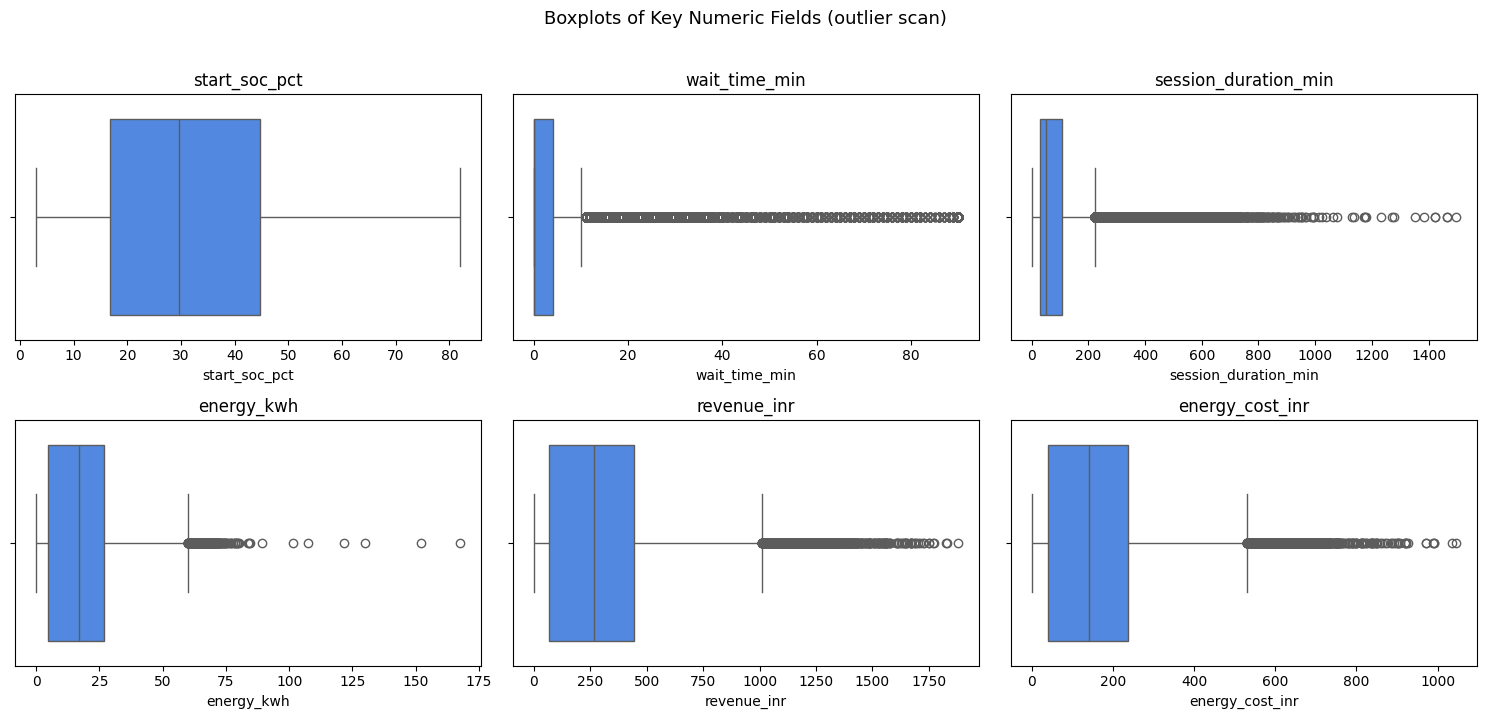

In [15]:
num_cols = ["start_soc_pct", "wait_time_min", "session_duration_min", "energy_kwh", "revenue_inr", "energy_cost_inr"]

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), num_cols):
    sns.boxplot(x=df[c], ax=ax, color="#3b82f6")
    ax.set_title(c)
plt.suptitle("Boxplots of Key Numeric Fields (outlier scan)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [16]:
def iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

outlier_summary = []
for c in num_cols:
    lo, hi = iqr_bounds(df[c])
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_summary.append([c, round(lo, 1), round(hi, 1), n_out, round(n_out/len(df)*100, 2)])

pd.DataFrame(outlier_summary, columns=["column", "iqr_low", "iqr_high", "outlier_count", "outlier_pct"])


,column,iqr_low,iqr_high,outlier_count,outlier_pct
0,start_soc_pct,-25.2,86.8,0,0.00
1,wait_time_min,-6.0,10.0,12554,14.46
2,session_duration_min,-85.5,222.5,10723,12.35
3,energy_kwh,-28.5,60.0,369,0.42
4,revenue_inr,-498.4,1011.6,1529,1.76
5,energy_cost_inr,-255.1,530.4,1146,1.32


In [17]:
validation = {
    "Rows after cleaning": len(df),
    "Columns": df.shape[1],
    "Remaining nulls": int(df.isnull().sum().sum()),
    "Remaining duplicate session_id": int(df.duplicated(subset=['session_id']).sum()),
    "Date range": f"{df.start_time.min().date()} -> {df.start_time.max().date()}",
    "Cities": df.city.nunique(),
    "Stations": df.station_id.nunique(),
}
pd.Series(validation)


,0
Rows after cleaning,86828
Columns,15
Remaining nulls,8
Remaining duplicate session_id,0
Date range,2025-01-01 -> 2025-09-18
Cities,9
Stations,105


In [18]:
df.to_csv("ev_charging_sessions_cleaned.csv", index=False)
print("Cleaned dataset saved -> ev_charging_sessions_cleaned.csv")


Cleaned dataset saved -> ev_charging_sessions_cleaned.csv


In [19]:
# Re-derive a couple of light convenience fields used throughout this sprint (raw fields only, no engineering yet)
df["hour"] = df["start_time"].dt.hour
df["weekday"] = df["start_time"].dt.day_name()
df["month"] = df["start_time"].dt.to_period("M").astype(str)
print(df.shape)


(86828, 18)


In [20]:
num_cols = ["start_soc_pct", "wait_time_min", "session_duration_min", "energy_kwh", "revenue_inr", "energy_cost_inr"]
desc = df[num_cols].agg(["mean", "median", lambda s: s.mode().iloc[0], "std", "var",
                          lambda s: s.max()-s.min(), "skew",
                          lambda s: s.kurt()]).T
desc.columns = ["mean", "median", "mode", "std", "variance", "range", "skew", "kurtosis"]
desc.round(2)


,mean,median,mode,std,variance,range,skew,kurtosis
start_soc_pct,32.08,29.70,3.0,19.13,365.97,79.00,0.49,-0.46
wait_time_min,4.76,0.00,0.0,11.27,126.91,90.00,3.75,17.33
session_duration_min,95.82,50.00,37.0,115.83,13416.31,1495.00,2.52,8.47
energy_kwh,17.83,16.96,0.0,13.93,194.00,167.54,0.68,0.30
revenue_inr,300.58,264.90,0.0,259.72,67456.43,1880.30,1.09,1.42
energy_cost_inr,158.57,141.98,0.0,132.13,17457.10,1045.16,1.00,1.24


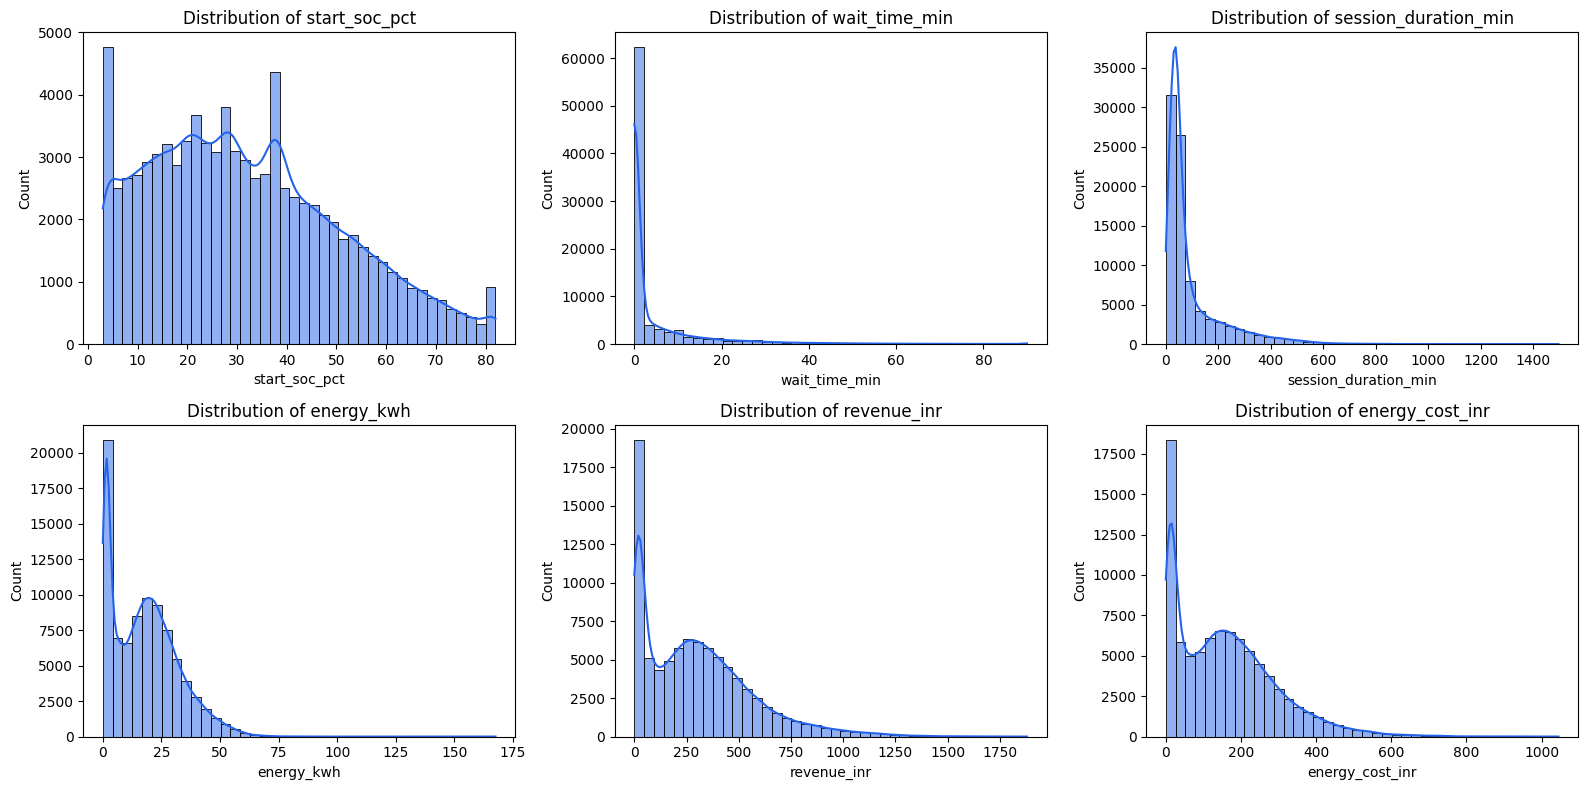

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(df[c], bins=40, kde=True, ax=ax, color="#2563eb")
    ax.set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()


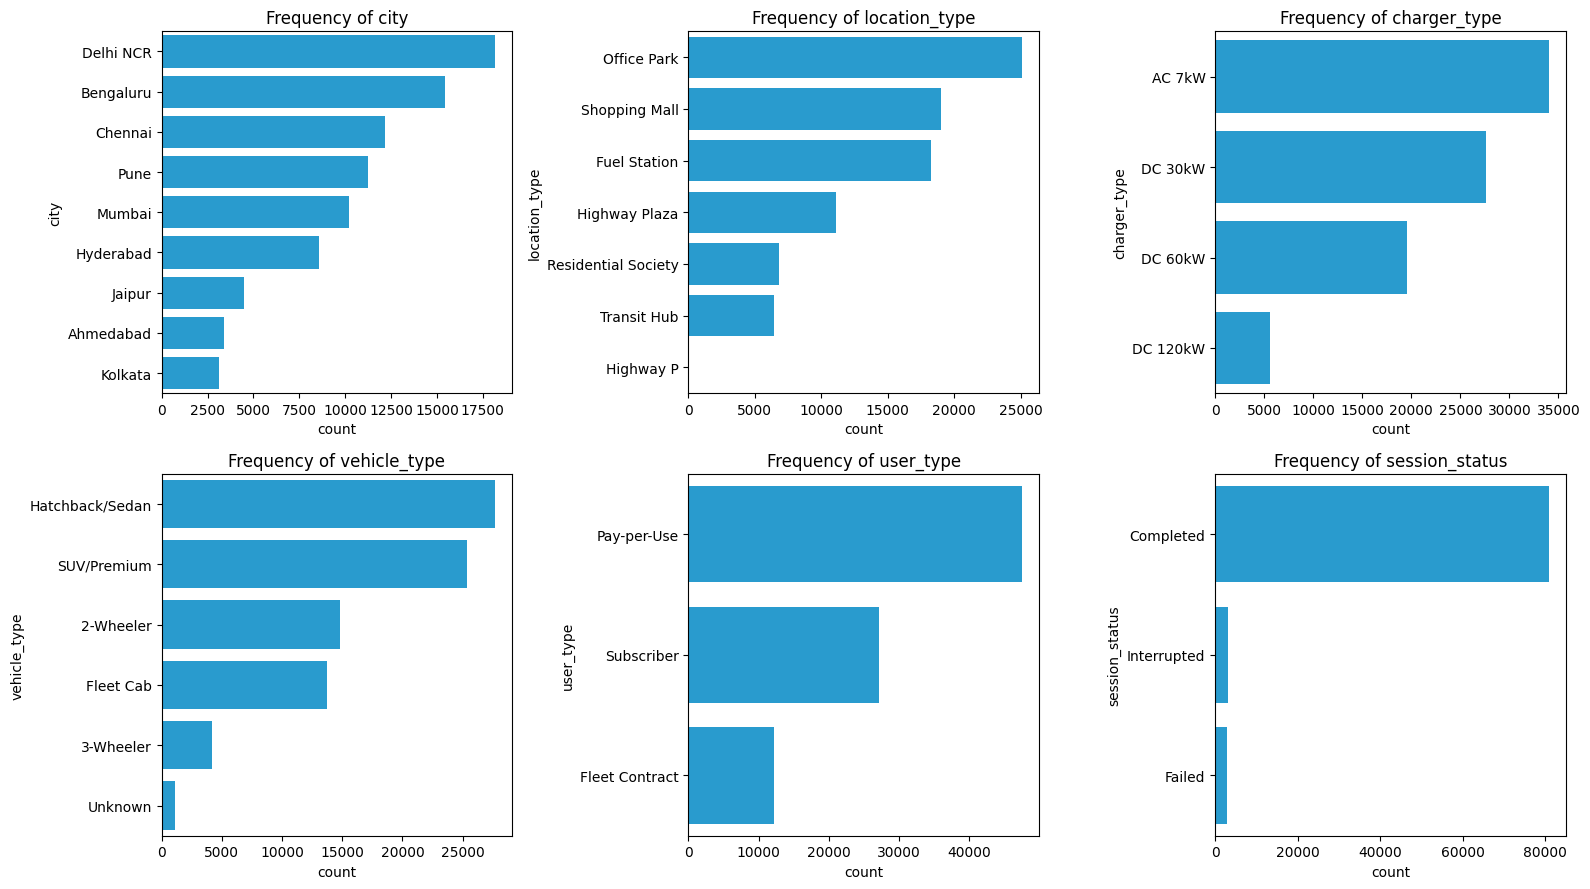

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cat_cols = ["city", "location_type", "charger_type", "vehicle_type", "user_type", "session_status"]
for ax, c in zip(axes.ravel(), cat_cols):
    order = df[c].value_counts().index
    sns.countplot(y=df[c], order=order, ax=ax, color="#0ea5e9")
    ax.set_title(f"Frequency of {c}")
plt.tight_layout()
plt.show()


In [23]:
for c in cat_cols:
    print(f"\n{c} value counts (%):")
    print((df[c].value_counts(normalize=True)*100).round(1))



city value counts (%):
city
Delhi NCR    21.0
Bengaluru    17.8
Chennai      14.0
Pune         13.0
Mumbai       11.8
Hyderabad     9.9
Jaipur        5.2
Ahmedabad     3.9
Kolkata       3.6
Name: proportion, dtype: float64

location_type value counts (%):
location_type
Office Park            28.9
Shopping Mall          21.9
Fuel Station           21.1
Highway Plaza          12.8
Residential Society     7.9
Transit Hub             7.4
Highway P               0.0
Name: proportion, dtype: float64

charger_type value counts (%):
charger_type
AC 7kW      39.2
DC 30kW     31.8
DC 60kW     22.5
DC 120kW     6.4
Name: proportion, dtype: float64

vehicle_type value counts (%):
vehicle_type
Hatchback/Sedan    31.9
SUV/Premium        29.2
2-Wheeler          17.0
Fleet Cab          15.8
3-Wheeler           4.8
Unknown             1.3
Name: proportion, dtype: float64

user_type value counts (%):
user_type
Pay-per-Use       54.8
Subscriber        31.2
Fleet Contract    14.0
Name: proportion, dtype:

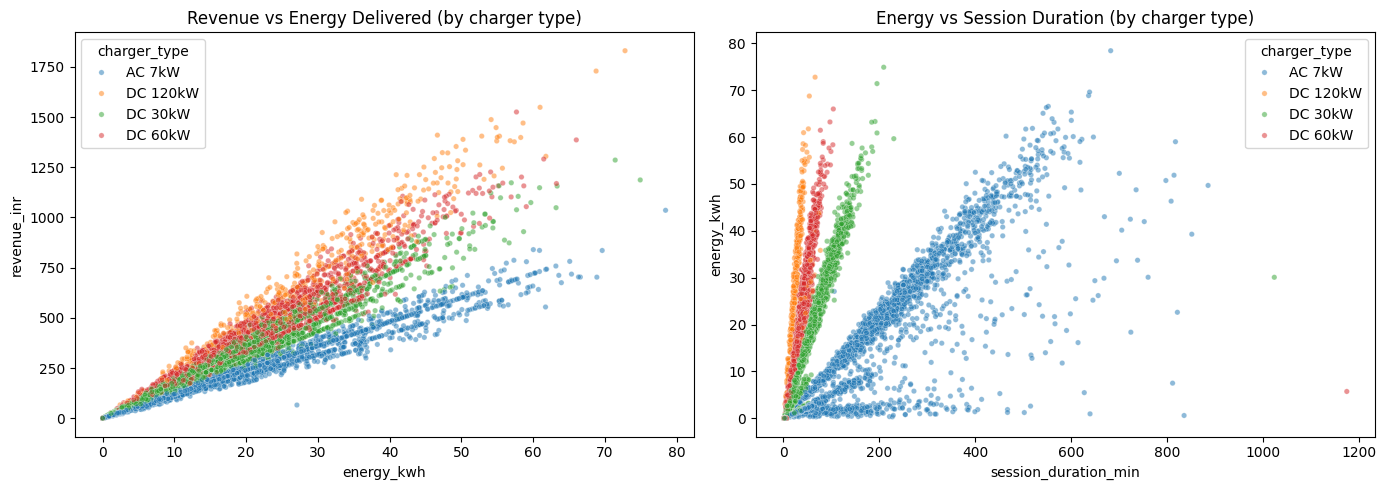

In [24]:
sample = df.sample(8000, random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=sample, x="energy_kwh", y="revenue_inr", hue="charger_type", alpha=0.5, ax=axes[0], s=15)
axes[0].set_title("Revenue vs Energy Delivered (by charger type)")
sns.scatterplot(data=sample, x="session_duration_min", y="energy_kwh", hue="charger_type", alpha=0.5, ax=axes[1], s=15)
axes[1].set_title("Energy vs Session Duration (by charger type)")
plt.tight_layout()
plt.show()


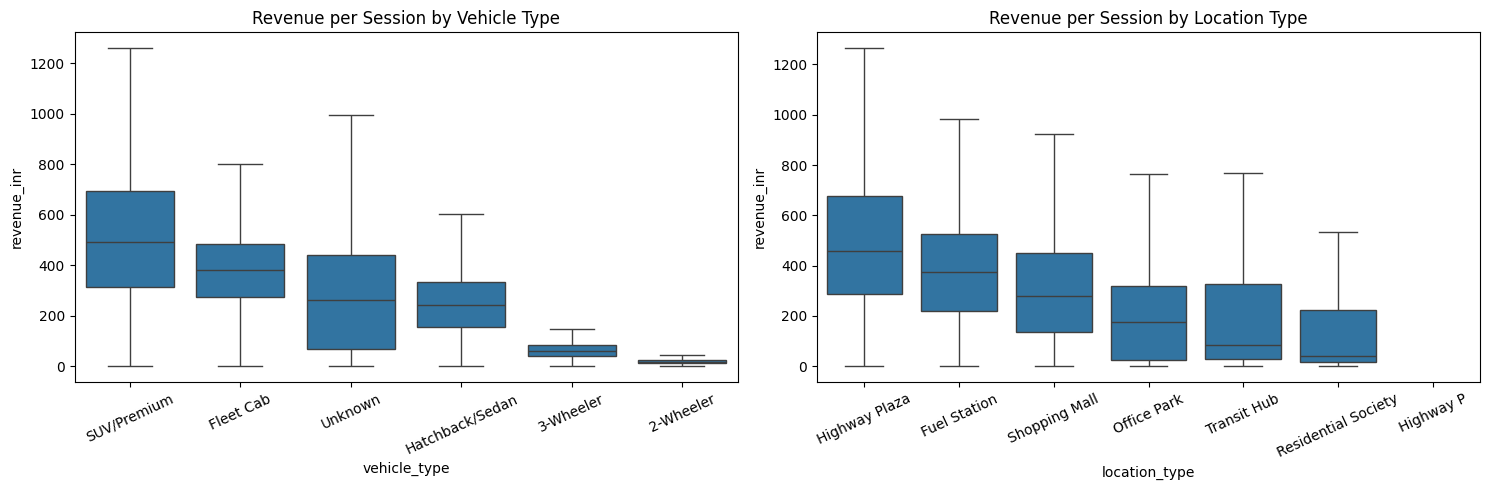

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order_v = df.groupby("vehicle_type", observed=True)["revenue_inr"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="vehicle_type", y="revenue_inr", order=order_v, ax=axes[0], showfliers=False)
axes[0].set_title("Revenue per Session by Vehicle Type")
axes[0].tick_params(axis='x', rotation=25)

order_l = df.groupby("location_type", observed=True)["revenue_inr"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="location_type", y="revenue_inr", order=order_l, ax=axes[1], showfliers=False)
axes[1].set_title("Revenue per Session by Location Type")
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


In [26]:
print("Median revenue by vehicle_type:")
print(df.groupby("vehicle_type", observed=True)["revenue_inr"].median().sort_values(ascending=False).round(1))
print("\nMedian revenue by location_type:")
print(df.groupby("location_type", observed=True)["revenue_inr"].median().sort_values(ascending=False).round(1))


Median revenue by vehicle_type:
vehicle_type
SUV/Premium        490.9
Fleet Cab          383.1
Unknown            260.6
Hatchback/Sedan    240.8
3-Wheeler           61.9
2-Wheeler           18.4
Name: revenue_inr, dtype: float64

Median revenue by location_type:
location_type
Highway Plaza          458.8
Fuel Station           375.7
Shopping Mall          281.2
Office Park            176.6
Transit Hub             85.8
Residential Society     41.5
Highway P                NaN
Name: revenue_inr, dtype: float64


In [27]:
ct = pd.crosstab(df["charger_type"], df["session_status"], normalize="index") * 100
ct = ct[["Completed", "Interrupted", "Failed"]].round(2)
ct


session_status,Completed,Interrupted,Failed
charger_type,,,
AC 7kW,94.70,3.23,2.06
DC 120kW,89.87,4.11,6.02
DC 30kW,92.91,3.68,3.42
DC 60kW,92.23,3.59,4.18


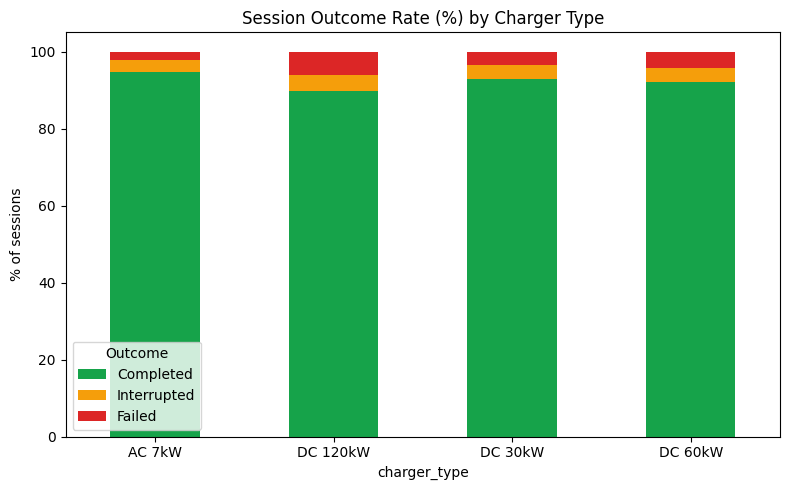

In [28]:
ct.plot(kind="bar", stacked=True, figsize=(8,5), color=["#16a34a", "#f59e0b", "#dc2626"])
plt.title("Session Outcome Rate (%) by Charger Type")
plt.ylabel("% of sessions")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()


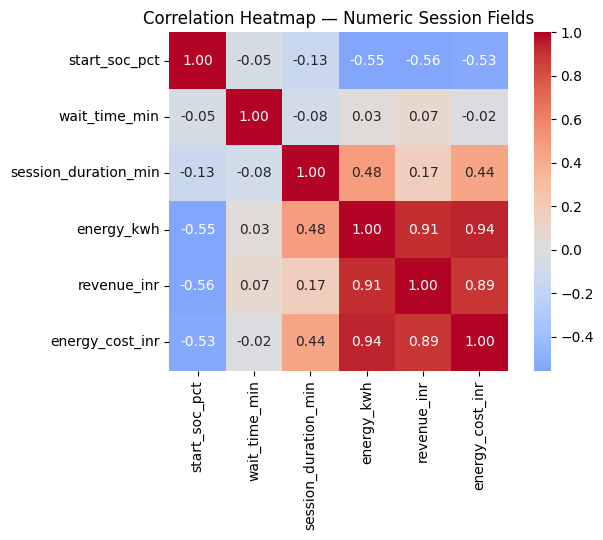

In [29]:
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(7,5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Numeric Session Fields")
plt.tight_layout()
plt.show()


In [30]:
# City x Vehicle type average revenue -- a multivariate demand/value view
pivot_cv = df.pivot_table(values="revenue_inr", index="city", columns="vehicle_type",
                           aggfunc="mean", observed=True).round(0)
pivot_cv


vehicle_type,2-Wheeler,3-Wheeler,Fleet Cab,Hatchback/Sedan,SUV/Premium,Unknown
city,,,,,,
Ahmedabad,19.0,62.0,415.0,289.0,611.0,392.0
Bengaluru,18.0,61.0,360.0,222.0,446.0,233.0
Chennai,19.0,62.0,349.0,221.0,441.0,210.0
Delhi NCR,19.0,67.0,382.0,253.0,523.0,322.0
Hyderabad,19.0,67.0,382.0,268.0,549.0,314.0
Jaipur,20.0,59.0,361.0,309.0,651.0,396.0
Kolkata,20.0,60.0,338.0,244.0,486.0,225.0
Mumbai,20.0,68.0,415.0,286.0,609.0,386.0
Pune,20.0,59.0,349.0,242.0,482.0,265.0


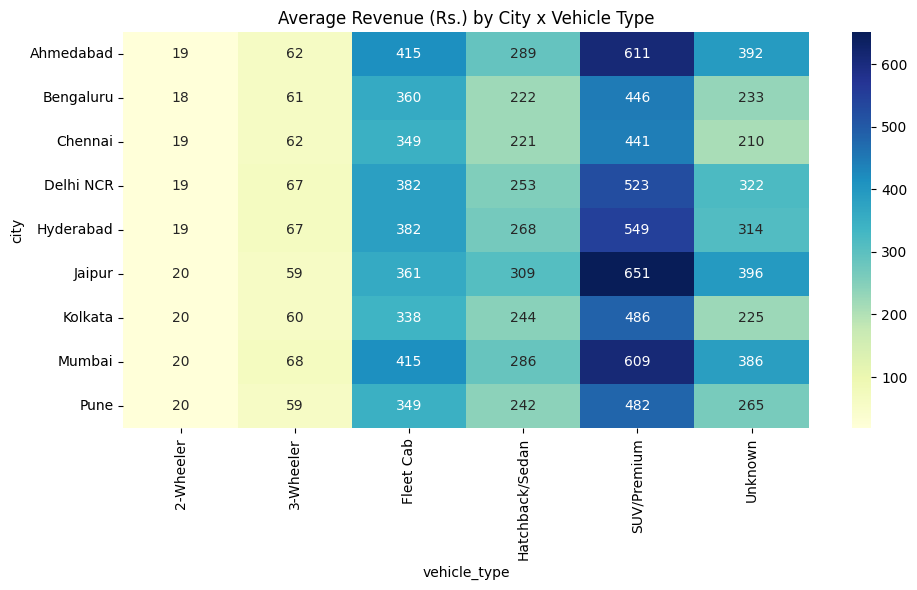

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot_cv, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Revenue (Rs.) by City x Vehicle Type")
plt.tight_layout()
plt.show()


In [32]:
city_summary = df.groupby("city", observed=True).agg(
    sessions=("session_id", "count"),
    total_revenue=("revenue_inr", "sum"),
    total_cost=("energy_cost_inr", "sum"),
    avg_revenue=("revenue_inr", "mean"),
    fail_rate_pct=("session_status", lambda s: (s == "Failed").mean()*100),
).assign(total_margin=lambda d: d.total_revenue - d.total_cost)
city_summary = city_summary.sort_values("total_revenue", ascending=False).round(1)
city_summary


,sessions,total_revenue,total_cost,avg_revenue,fail_rate_pct,total_margin
city,,,,,,
Delhi NCR,18192,5751149.6,2769317.3,316.1,2.6,2981832.3
Mumbai,10236,3726224.2,2084604.2,364.0,3.7,1641620.0
Bengaluru,15432,3629438.0,1850759.9,235.2,3.0,1778678.1
Pune,11264,3321424.8,1894546.9,294.9,2.3,1426877.9
Hyderabad,8588,2927392.5,1593367.5,340.9,3.3,1334025.0
Chennai,12150,2802901.7,1505026.8,230.7,2.7,1297874.8
Jaipur,4482,1712037.0,798811.1,382.1,6.8,913226.0
Ahmedabad,3386,1283311.9,651514.1,379.0,2.1,631797.8
Kolkata,3098,944604.0,620346.2,304.9,7.4,324257.9


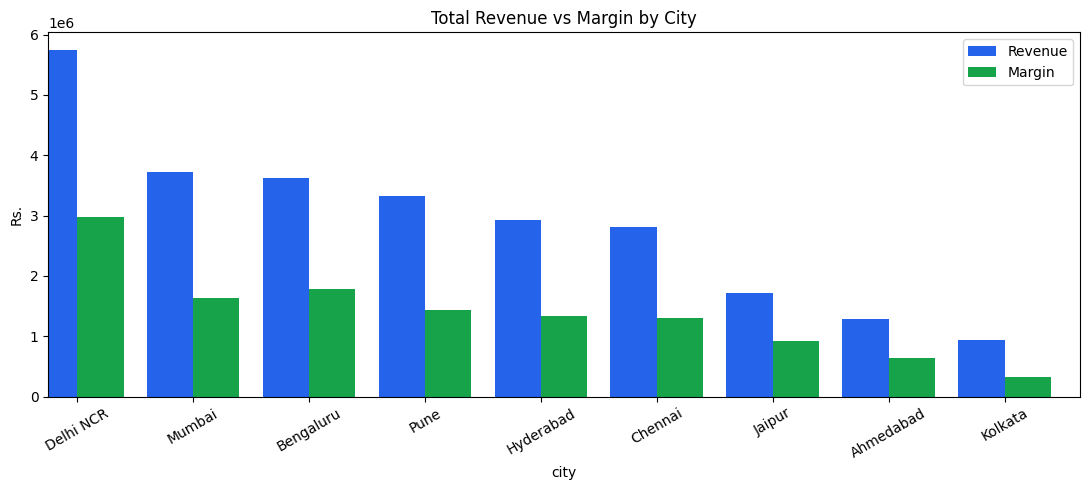

In [33]:
fig, ax1 = plt.subplots(figsize=(11,5))
city_summary["total_revenue"].plot(kind="bar", color="#2563eb", ax=ax1, position=1, width=0.4, label="Revenue")
city_summary["total_margin"].plot(kind="bar", color="#16a34a", ax=ax1, position=0, width=0.4, label="Margin")
ax1.set_ylabel("Rs.")
ax1.set_title("Total Revenue vs Margin by City")
ax1.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [34]:
pivot_1 = df.pivot_table(values="revenue_inr", index="city", columns="location_type",
                          aggfunc="sum", observed=True, fill_value=0).round(0)
pivot_1


location_type,Fuel Station,Highway P,Highway Plaza,Office Park,Residential Society,Shopping Mall,Transit Hub
city,,,,,,,
Ahmedabad,231428.0,0.0,833753.0,178869.0,39262.0,0.0,0.0
Bengaluru,1102577.0,0.0,36842.0,1664790.0,267025.0,338109.0,220095.0
Chennai,62687.0,0.0,188106.0,1350272.0,11901.0,666960.0,522976.0
Delhi NCR,3492110.0,0.0,174440.0,742889.0,194175.0,1010635.0,136901.0
Hyderabad,998053.0,0.0,866049.0,345708.0,69270.0,648313.0,0.0
Jaipur,111712.0,0.0,1347613.0,6750.0,0.0,0.0,245961.0
Kolkata,0.0,0.0,333019.0,0.0,19883.0,503105.0,88597.0
Mumbai,1192720.0,0.0,1694925.0,592058.0,157904.0,88618.0,0.0
Pune,0.0,0.0,88859.0,314880.0,168601.0,2747394.0,1691.0


In [35]:
pivot_2 = df.pivot_table(values=["energy_kwh", "wait_time_min"], index="charger_type", columns="user_type",
                          aggfunc="mean", observed=True).round(2)
pivot_2


energy_kwh                         wait_time_min              \
user_type    Fleet Contract Pay-per-Use Subscriber Fleet Contract Pay-per-Use   
charger_type                                                                    
AC 7kW                18.40       14.56      14.44           2.52        2.72   
DC 120kW              22.02       27.01      26.89           7.99        7.62   
DC 30kW               20.09       16.25      16.38           5.82        5.51   
DC 60kW               22.33       22.18      22.09           6.51        6.45   

                         
user_type    Subscriber  
charger_type             
AC 7kW             2.78  
DC 120kW           7.19  
DC 30kW            5.39  
DC 60kW            6.28

In [36]:
ct_city_status = pd.crosstab(df["city"], df["session_status"], normalize="index") * 100
ct_city_status[["Completed", "Interrupted", "Failed"]].round(2).sort_values("Failed", ascending=False)


session_status,Completed,Interrupted,Failed
city,,,
Kolkata,89.35,3.29,7.36
Jaipur,89.38,3.79,6.83
Mumbai,92.70,3.61,3.68
Hyderabad,93.74,2.99,3.27
Bengaluru,93.75,3.23,3.02
Chennai,93.61,3.65,2.74
Delhi NCR,93.78,3.58,2.64
Pune,93.66,4.07,2.27
Ahmedabad,94.98,2.89,2.13


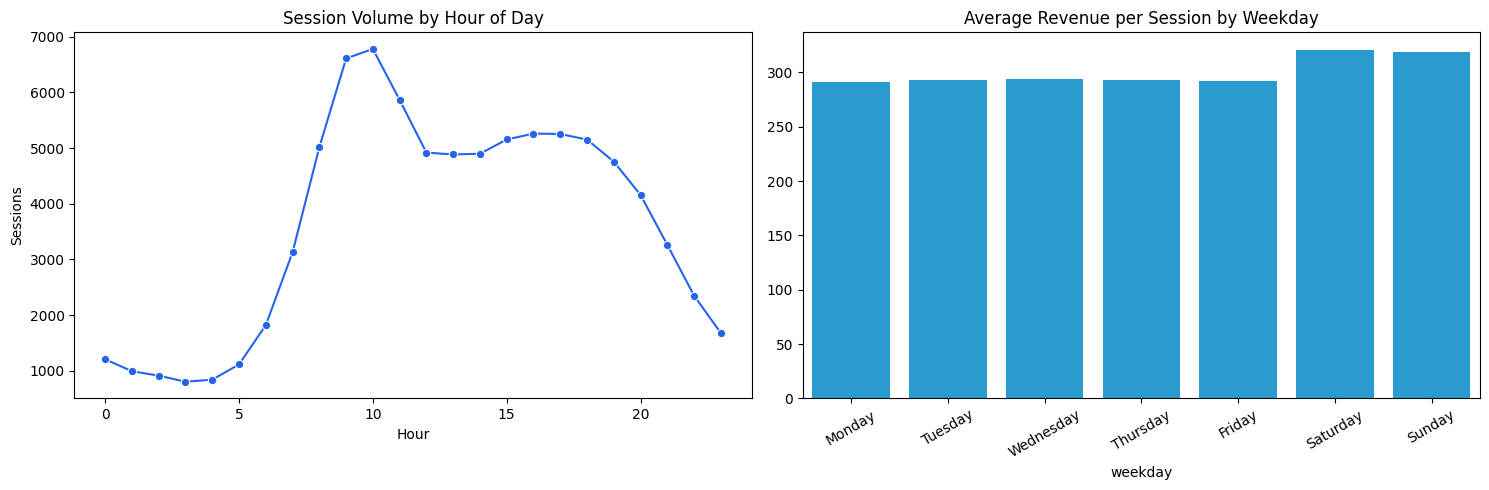

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
hourly = df.groupby("hour", observed=True).size()
sns.lineplot(x=hourly.index, y=hourly.values, marker="o", ax=axes[0], color="#2563eb")
axes[0].set_title("Session Volume by Hour of Day")
axes[0].set_xlabel("Hour"); axes[0].set_ylabel("Sessions")

weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_rev = df.groupby("weekday", observed=True)["revenue_inr"].mean().reindex(weekday_order)
sns.barplot(x=weekday_rev.index, y=weekday_rev.values, ax=axes[1], color="#0ea5e9")
axes[1].set_title("Average Revenue per Session by Weekday")
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


/tmp/ipykernel_691/3854003499.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly["month"], rotation=45)


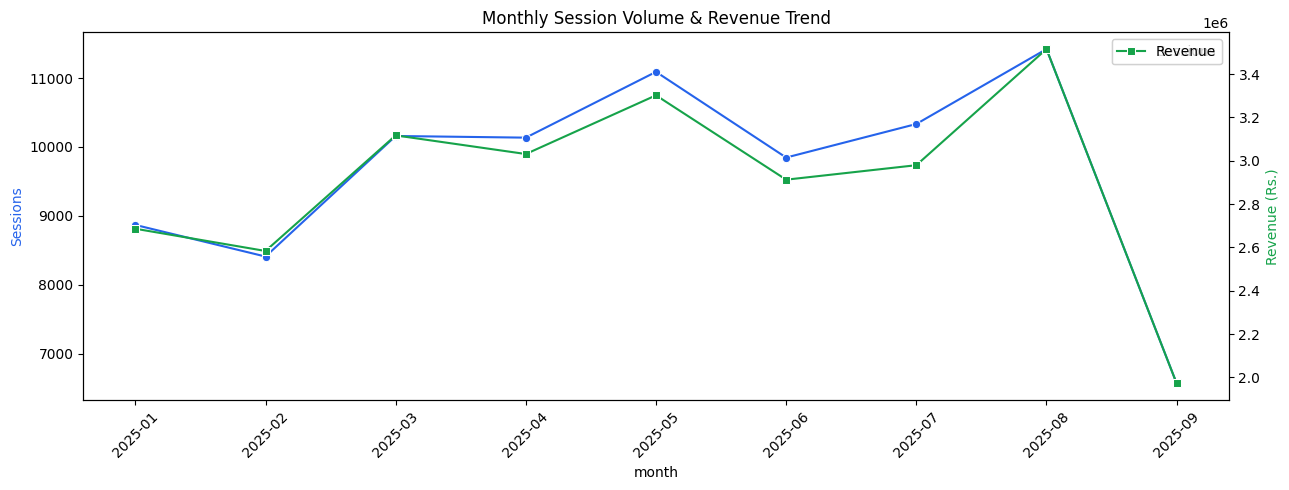

In [38]:
monthly = df.groupby("month", observed=True).agg(sessions=("session_id","count"), revenue=("revenue_inr","sum")).reset_index()
fig, ax1 = plt.subplots(figsize=(13,5))
ax2 = ax1.twinx()
sns.lineplot(data=monthly, x="month", y="sessions", ax=ax1, color="#2563eb", marker="o", label="Sessions")
sns.lineplot(data=monthly, x="month", y="revenue", ax=ax2, color="#16a34a", marker="s", label="Revenue")
ax1.set_ylabel("Sessions", color="#2563eb"); ax2.set_ylabel("Revenue (Rs.)", color="#16a34a")
ax1.set_xticklabels(monthly["month"], rotation=45)
plt.title("Monthly Session Volume & Revenue Trend")
fig.tight_layout()
plt.show()


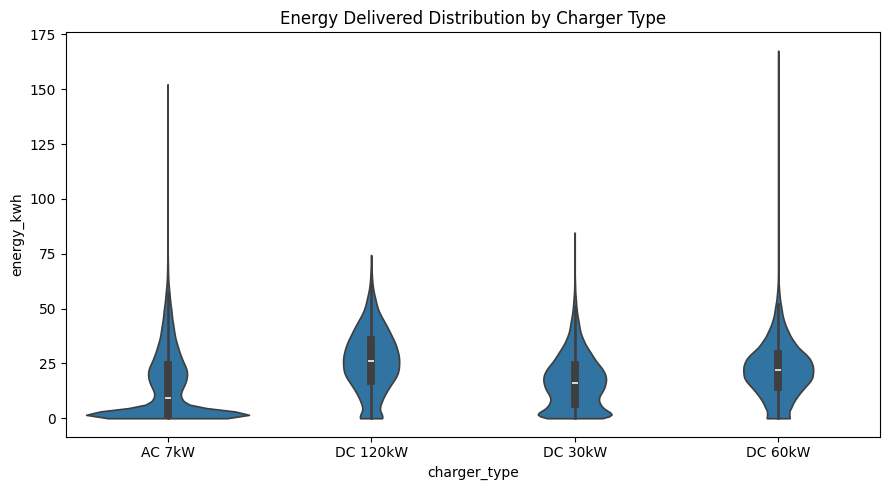

In [39]:
fig, ax = plt.subplots(figsize=(9,5))
sns.violinplot(data=df, x="charger_type", y="energy_kwh", ax=ax, cut=0)
ax.set_title("Energy Delivered Distribution by Charger Type")
plt.tight_layout()
plt.show()


In [40]:
df["margin_inr"] = df["revenue_inr"] - df["energy_cost_inr"]
stat_cols = ["energy_kwh", "revenue_inr", "energy_cost_inr", "margin_inr"]

stats_table = pd.DataFrame({
    "mean": df[stat_cols].mean(),
    "median": df[stat_cols].median(),
    "std_dev": df[stat_cols].std(),
    "variance": df[stat_cols].var(),
    "range": df[stat_cols].max() - df[stat_cols].min(),
    "IQR": df[stat_cols].quantile(.75) - df[stat_cols].quantile(.25),
}).round(2)
stats_table


,mean,median,std_dev,variance,range,IQR
energy_kwh,17.83,16.96,13.93,194.00,167.54,22.11
revenue_inr,300.58,264.90,259.72,67456.43,1880.30,377.50
energy_cost_inr,158.57,141.98,132.13,17457.10,1045.16,196.39
margin_inr,142.01,100.22,154.23,23788.24,1521.60,199.36


In [41]:
print("Covariance matrix:")
print(df[stat_cols].cov().round(1))
print("\nCorrelation matrix:")
print(df[stat_cols].corr().round(2))


Covariance matrix:
                 energy_kwh  revenue_inr  energy_cost_inr  margin_inr
energy_kwh            194.0       3291.2           1726.0      1565.2
revenue_inr          3291.2      67456.4          30562.6     36893.8
energy_cost_inr      1726.0      30562.6          17457.1     13105.5
margin_inr           1565.2      36893.8          13105.5     23788.2

Correlation matrix:
                 energy_kwh  revenue_inr  energy_cost_inr  margin_inr
energy_kwh             1.00         0.91             0.94        0.73
revenue_inr            0.91         1.00             0.89        0.92
energy_cost_inr        0.94         0.89             1.00        0.64
margin_inr             0.73         0.92             0.64        1.00


In [42]:
contingency = pd.crosstab(df["charger_type"], df["session_status"])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square statistic = {chi2:.2f}, dof = {dof}, p-value = {p_val:.2e}")
print("Decision:", "Reject H0 — reliability significantly differs by charger type" if p_val < 0.05 else "Fail to reject H0")


Chi-square statistic = 368.66, dof = 6, p-value = 1.52e-76
Decision: Reject H0 — reliability significantly differs by charger type


In [43]:
groups = [g["revenue_inr"].values for _, g in df.groupby("city", observed=True)]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic = {f_stat:.2f}, p-value = {p_val:.2e}")
print("Decision:", "Reject H0 — average revenue per session differs significantly by city" if p_val < 0.05 else "Fail to reject H0")


F-statistic = nan, p-value = nan
Decision: Fail to reject H0


In [44]:
df["is_weekend"] = df["weekday"].isin(["Saturday", "Sunday"])
weekend_energy = df.loc[df.is_weekend, "energy_kwh"]
weekday_energy = df.loc[~df.is_weekend, "energy_kwh"]

t_stat, p_val = stats.ttest_ind(weekend_energy, weekday_energy, equal_var=False)
print(f"Weekend mean: {weekend_energy.mean():.2f} kWh | Weekday mean: {weekday_energy.mean():.2f} kWh")
print(f"T-statistic = {t_stat:.2f}, p-value = {p_val:.4f}")
print("Decision:", "Reject H0 — weekend/weekday energy usage differs significantly" if p_val < 0.05 else "Fail to reject H0 — no significant difference")


Weekend mean: 18.43 kWh | Weekday mean: 17.57 kWh
T-statistic = nan, p-value = nan
Decision: Fail to reject H0 — no significant difference


In [45]:
contingency_2 = pd.crosstab(df["user_type"], df["session_status"])
chi2_2, p_val_2, dof_2, _ = stats.chi2_contingency(contingency_2)
print(f"Chi-square statistic = {chi2_2:.2f}, dof = {dof_2}, p-value = {p_val_2:.2e}")
print("Decision:", "Reject H0 — outcome depends on customer type" if p_val_2 < 0.05 else "Fail to reject H0")
print("\nOutcome rate (%) by user_type:")
print((contingency_2.div(contingency_2.sum(axis=1), axis=0)*100).round(2))


Chi-square statistic = 19.07, dof = 4, p-value = 7.60e-04
Decision: Reject H0 — outcome depends on customer type

Outcome rate (%) by user_type:
session_status  Completed  Failed  Interrupted
user_type                                     
Fleet Contract      92.60    3.81         3.59
Pay-per-Use         93.42    3.16         3.42
Subscriber          93.29    3.07         3.64


In [46]:
def mean_ci(series, confidence=0.95):
    n = series.shape[0]
    m = series.mean()
    se = series.std(ddof=1) / np.sqrt(n)
    h = se * stats.t.ppf((1+confidence)/2, n-1)
    return m, m-h, m+h

for col in ["revenue_inr", "margin_inr", "energy_kwh"]:
    m, lo, hi = mean_ci(df[col])
    print(f"{col:15s} 95% CI for the mean: {lo:,.2f}  <=  mu  <=  {hi:,.2f}   (point estimate: {m:,.2f})")


revenue_inr     95% CI for the mean: 298.85  <=  mu  <=  302.31   (point estimate: 300.58)
margin_inr      95% CI for the mean: 140.98  <=  mu  <=  143.03   (point estimate: 142.01)
energy_kwh      95% CI for the mean: 17.73  <=  mu  <=  17.92   (point estimate: 17.83)


In [47]:
# 1. Time-of-day demand window -> staffing / dynamic pricing windows (Sprint 2 finding: 9AM-8PM peak)
def time_bucket(h):
    if 0 <= h < 6:
        return "Late Night (12-6AM)"
    elif 6 <= h < 9:
        return "Morning Ramp (6-9AM)"
    elif 9 <= h < 20:
        return "Peak (9AM-8PM)"
    else:
        return "Evening Taper (8PM-12AM)"
df["time_window"] = df["hour"].apply(time_bucket)

# 2. Margin % -> true profitability per session, independent of ticket size
df["margin_pct"] = np.where(df["revenue_inr"] > 0, (df["margin_inr"] / df["revenue_inr"]) * 100, np.nan)

# 3. Revenue per kWh -> effective realized price, comparable across charger types
df["revenue_per_kwh"] = np.where(df["energy_kwh"] > 0, df["revenue_inr"] / df["energy_kwh"], np.nan)

# 4. Charging speed (kWh per minute) -> true utilization efficiency, better than raw duration
df["charging_speed_kwh_per_min"] = np.where(df["session_duration_min"] > 0,
                                             df["energy_kwh"] / df["session_duration_min"], np.nan)

# 5. Session value tier -> quartile-based value segmentation for loyalty/prioritization programs
df["value_tier"] = pd.qcut(df["revenue_inr"], q=4, labels=["Low", "Mid-Low", "Mid-High", "High"])

# 6. Reliability risk flag at the charger-type level -> feeds a maintenance-priority score
charger_fail_rate = df.groupby("charger_type", observed=True)["session_status"].apply(lambda s: (s != "Completed").mean())
df["charger_type_failure_rate"] = df["charger_type"].map(charger_fail_rate).astype(float)

# 7. Congestion flag -> did this session experience a meaningful queue?
df["had_wait"] = df["wait_time_min"] > 0

# 8. Combined session outcome flag (binary) -> simplifies reliability modeling/reporting
df["is_unsuccessful"] = df["session_status"] != "Completed"

df[["time_window","margin_pct","revenue_per_kwh","charging_speed_kwh_per_min",
    "value_tier","charger_type_failure_rate","had_wait","is_unsuccessful"]].head()


,time_window,margin_pct,revenue_per_kwh,charging_speed_kwh_per_min,value_tier,charger_type_failure_rate,had_wait,is_unsuccessful
0,Late Night (12-6AM),24.811433,10.198381,0.046604,Low,0.052956,False,False
1,Late Night (12-6AM),34.267184,11.869841,0.273913,Mid-Low,0.070914,False,False
2,Late Night (12-6AM),62.056847,17.848834,0.717414,High,0.077654,False,False
3,Late Night (12-6AM),56.622941,15.707727,0.470000,Mid-High,0.077654,False,False
4,Late Night (12-6AM),48.666293,17.493515,0.619804,High,0.077654,False,False


In [48]:
print("Mean margin_pct by value_tier:")
print(df.groupby("value_tier", observed=True)["margin_pct"].mean().round(1))

print("\nMean revenue_per_kwh by charger_type:")
print(df.groupby("charger_type", observed=True)["revenue_per_kwh"].mean().round(2))

print("\nUnsuccessful-session rate by time_window:")
print((df.groupby("time_window", observed=True)["is_unsuccessful"].mean()*100).round(2))


Mean margin_pct by value_tier:
value_tier
Low         30.0
Mid-Low     39.7
Mid-High    43.5
High        50.4
Name: margin_pct, dtype: float64

Mean revenue_per_kwh by charger_type:
charger_type
AC 7kW      11.59
DC 120kW    23.87
DC 30kW     17.29
DC 60kW     20.13
Name: revenue_per_kwh, dtype: float64

Unsuccessful-session rate by time_window:
time_window
Evening Taper (8PM-12AM)    6.91
Late Night (12-6AM)         6.49
Morning Ramp (6-9AM)        6.32
Peak (9AM-8PM)              6.79
Name: is_unsuccessful, dtype: float64


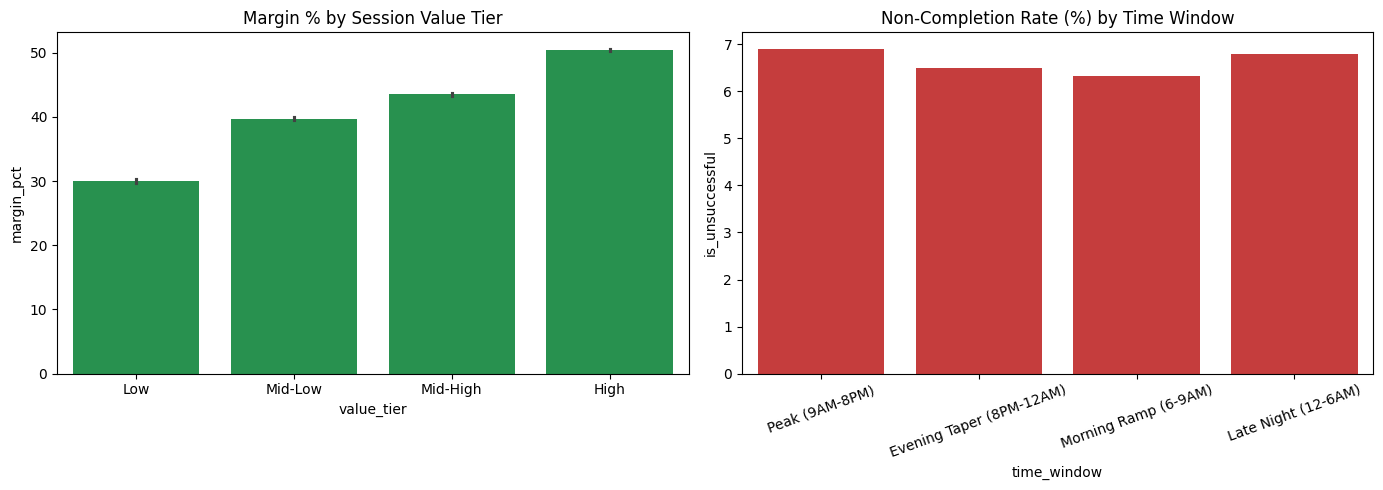

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(data=df, x="value_tier", y="margin_pct", ax=axes[0], order=["Low","Mid-Low","Mid-High","High"], color="#16a34a")
axes[0].set_title("Margin % by Session Value Tier")

sns.barplot(x=df["time_window"].value_counts().index, y=(df.groupby("time_window", observed=True)["is_unsuccessful"].mean()*100),
            ax=axes[1], color="#dc2626")
axes[1].set_title("Non-Completion Rate (%) by Time Window")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


In [50]:
df.to_csv("ev_charging_sessions_features.csv", index=False)
print("Feature-engineered dataset saved -> ev_charging_sessions_features.csv")
print("Final shape:", df.shape)


Feature-engineered dataset saved -> ev_charging_sessions_features.csv
Final shape: (86828, 28)
